# End-to-End Sales Forecasting & Demand Intelligence System

## Internship Project

### Objectives
- Data Cleaning
- Exploratory Data Analysis
- Time Series Analysis
- Time Series Decomposition
- Stationarity Testing
- Forecasting
- Anomaly Detection
- Product Segmentation
- Business Dashboard

In [45]:
# ================================
# Import Required Libraries
# ================================

import warnings
warnings.filterwarnings("ignore")

import os
os.makedirs("charts", exist_ok=True)

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

plt.style.use("ggplot")

In [46]:
# ================================
# Helper Functions
# ================================

def save_chart(name):
    plt.tight_layout()
    plt.savefig(
        f"charts/{name}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


def adf_test(series):

    result = adfuller(series.dropna())

    print("="*60)
    print("ADF Statistic :", result[0])
    print("P-value       :", result[1])
    print("="*60)

    if result[1] < 0.05:
        print("Series is Stationary")
    else:
        print("Series is NOT Stationary")

In [47]:
# ================================
# Load Dataset
# ================================

df = pd.read_csv(
    "train.csv",
    encoding="latin1"
)

print(df.shape)

df.head()

(9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [48]:
df.info()

df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


In [49]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [50]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [52]:
# Remove duplicates

df.drop_duplicates(inplace=True)

# Convert Date

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)
# Sort

df.sort_values(
    "Order Date",
    inplace=True
)

drop_cols = [
    "Row ID",
    "Customer ID",
    "Customer Name",
    "Postal Code"
]

existing = [c for c in drop_cols if c in df.columns]

df.drop(
    columns=existing,
    inplace=True
)

df.reset_index(
    drop=True,
    inplace=True
)

print(df.shape)

(9800, 14)


In [ ]:
df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month

df["Month_Name"] = df["Order Date"].dt.onth_name()

df["Quarter"] = df["Order Date"].dt.quarter

df["Week"] = df["Order Date"].dt.to_period("W").astype(str)

df["Shipping Days"] = (
    df["Ship Date"] -
    df["Order Date"]
).dt.days

In [54]:
df.to_csv(
    "clean_superstore.csv",
    index=False
)

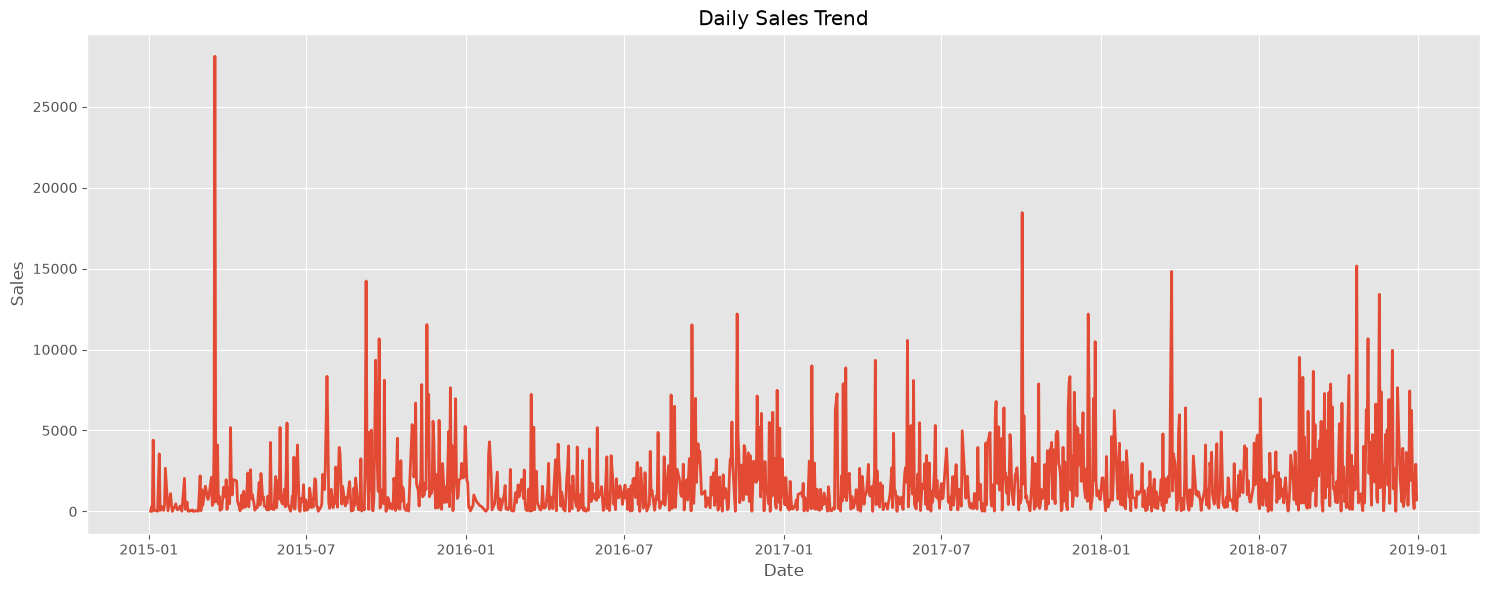

In [55]:
daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
)

daily_sales.to_csv(
    "daily_sales.csv"
)

plt.figure(figsize=(15,6))

plt.plot(
    daily_sales,
    linewidth=2
)

plt.title("Daily Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

save_chart("daily_sales")

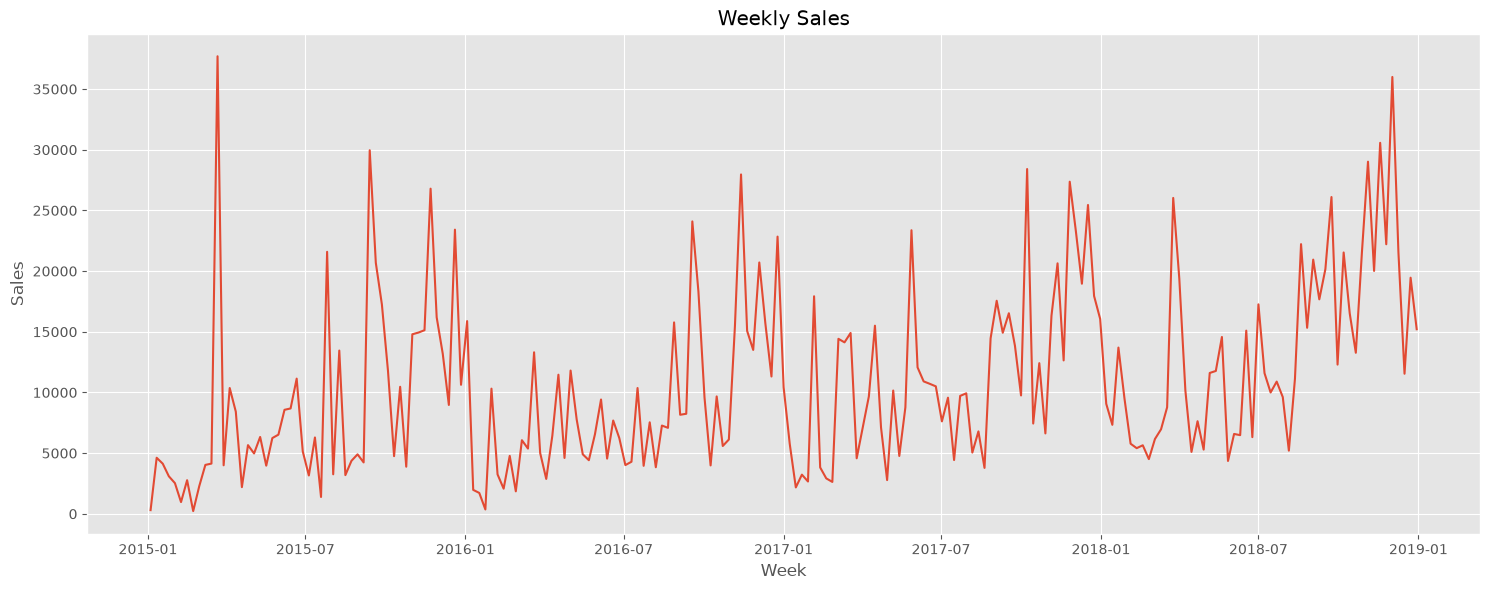

In [56]:
weekly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="W"
        )
    )["Sales"]
    .sum()
)

weekly_sales.to_csv(
    "weekly_sales.csv"
)

plt.figure(figsize=(15,6))

plt.plot(weekly_sales)

plt.title("Weekly Sales")

plt.xlabel("Week")

plt.ylabel("Sales")

save_chart("weekly_sales")

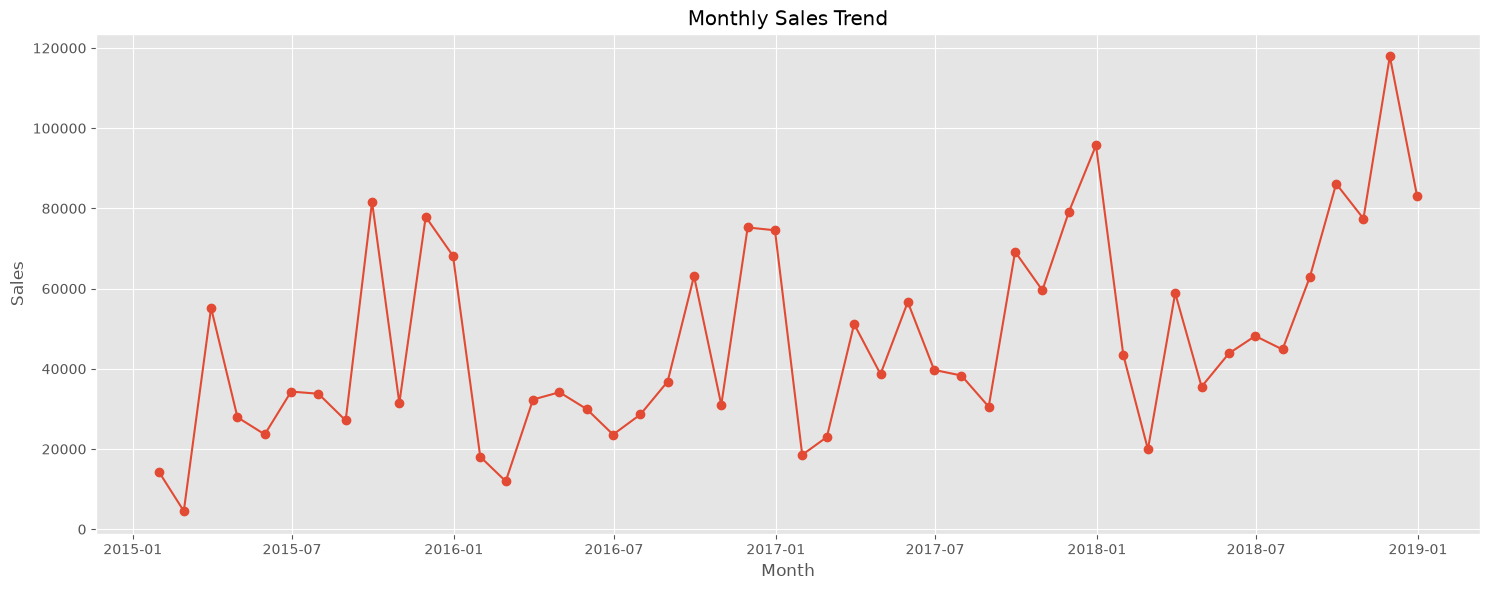

In [ ]:
onthly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="ME"
        )
    )["Sales"]
    .sum()
)

monthly_sales.to_csv(
    "monthly_sales.csv"
)

plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales,
    marker="o"
)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

save_chart("monthly_sales_trend")

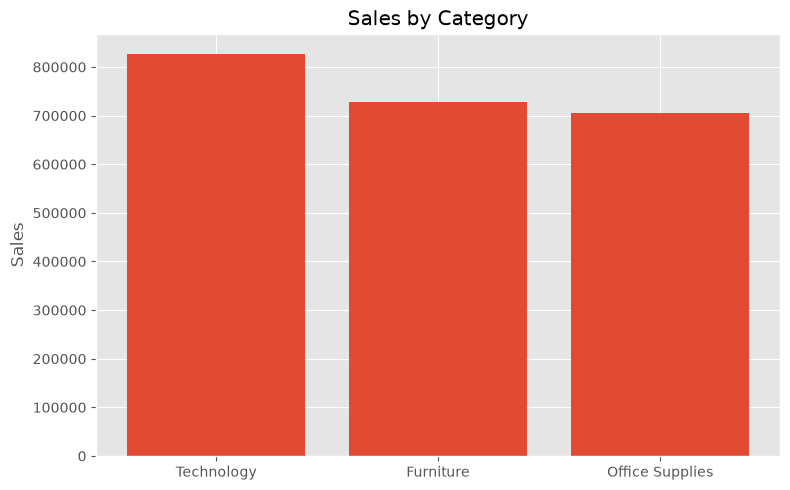

In [59]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(
          ascending=False
      )
)

plt.figure(figsize=(8,5))

plt.bar(
    category_sales.index,
    category_sales.values
)

plt.title("Sales by Category")

plt.ylabel("Sales")

save_chart("category_sales")

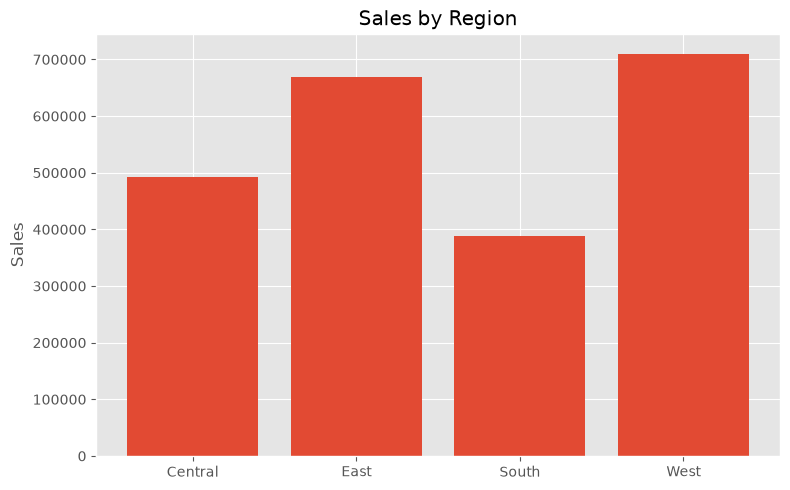

In [60]:
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
)

plt.figure(figsize=(8,5))

plt.bar(
    region_sales.index,
    region_sales.values
)

plt.title("Sales by Region")

plt.ylabel("Sales")

save_chart("region_sales")

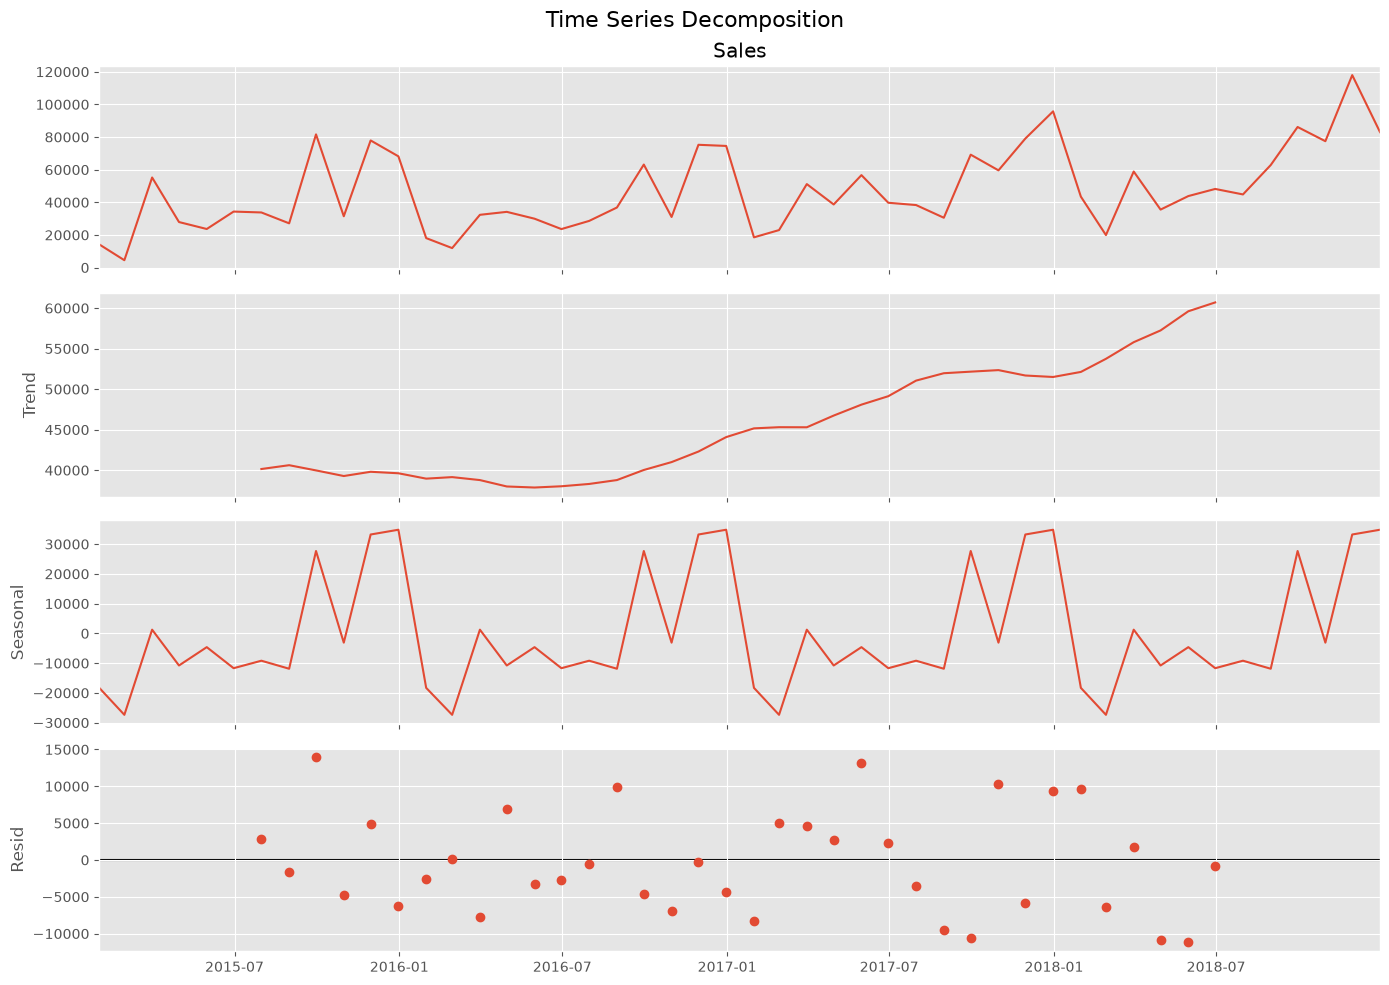

In [ ]:
decomposition = seasonal_decompose(
    s,
    model="additive",
    period=12
)

fig = decomposition.plot()

fig.set_size_inches(14,10)

plt.suptitle(
    "Time Series Decomposition",
    fontsize=16
)

save_chart("decomposition")

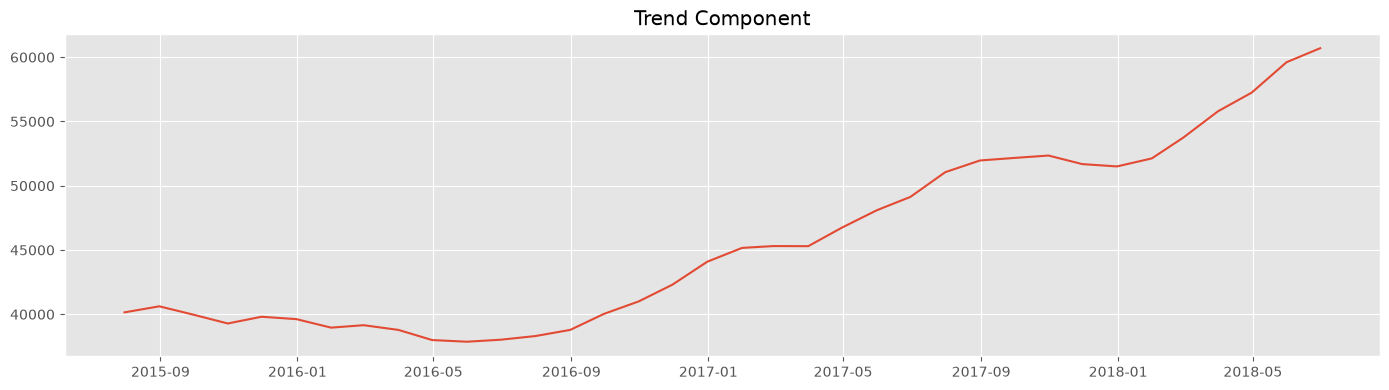

In [62]:
plt.figure(figsize=(14,4))

plt.plot(
    decomposition.trend
)

plt.title("Trend Component")

save_chart("trend_component")

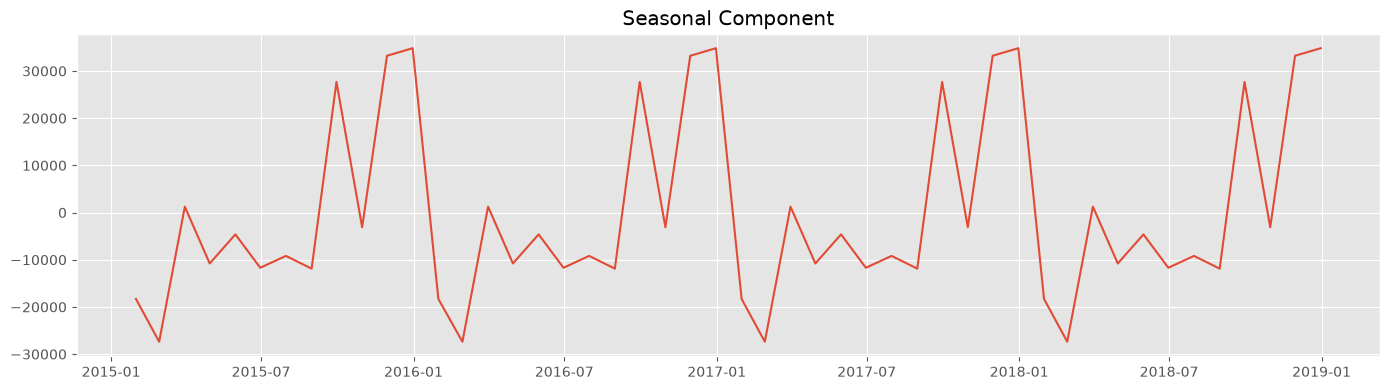

In [63]:
plt.figure(figsize=(14,4))

plt.plot(
    decomposition.seasonal
)

plt.title("Seasonal Component")

save_chart("seasonal_component")

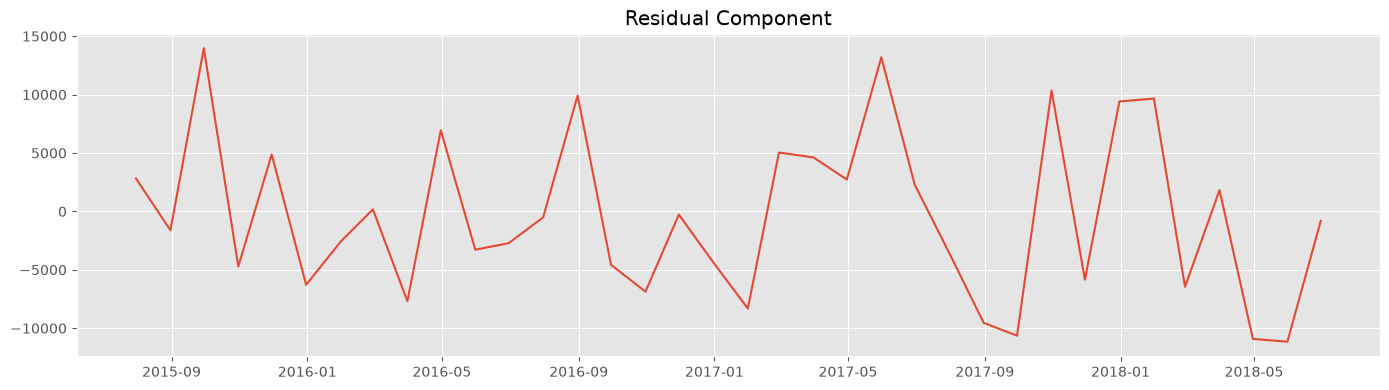

In [64]:
plt.figure(figsize=(14,4))

plt.plot(
    decomposition.resid
)

plt.title("Residual Component")

save_chart("residual_component")

In [ ]:
print("Original Series")

adf_test(
    hly_sales
)

Original Series
ADF Statistic : -4.416136761430768
P-value       : 0.00027791039276670677
Series is Stationary


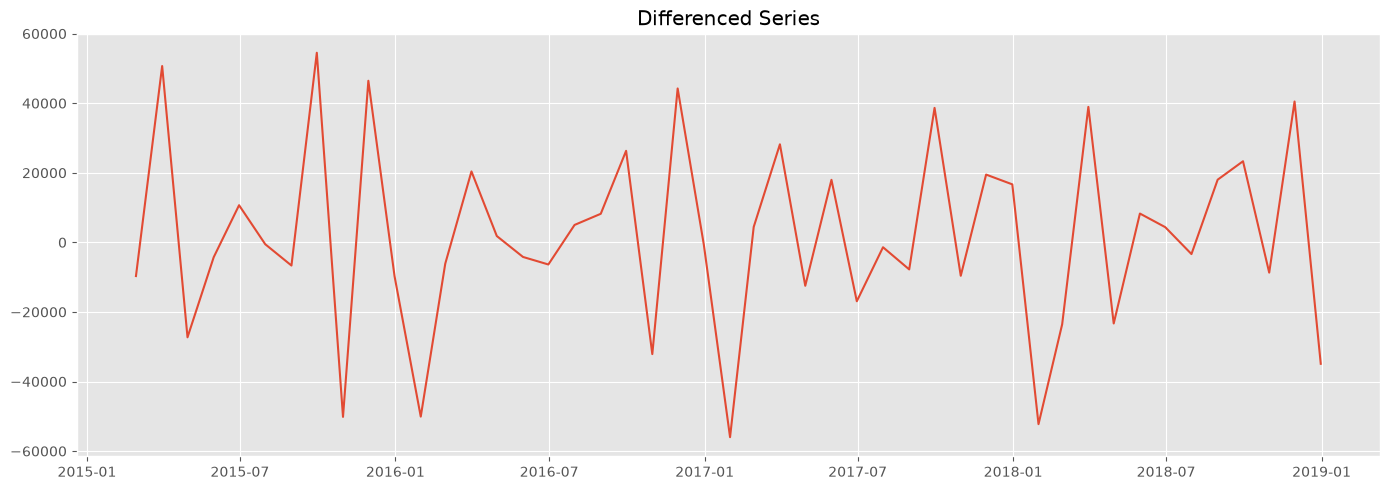

In [66]:
monthly_diff = (
    monthly_sales
    .diff()
    .dropna()
)

plt.figure(figsize=(14,5))

plt.plot(
    monthly_diff
)

plt.title(
    "Differenced Series"
)

save_chart("differenced_series")

In [67]:
print("Differenced Series")

adf_test(
    monthly_diff
)

Differenced Series
ADF Statistic : -8.727061830353266
P-value       : 3.266917547279664e-14
Series is Stationary


# Business Insights

### Monthly Trend
Sales generally show an increasing trend across the available years, indicating business growth over time.

### Seasonality
The decomposition reveals recurring seasonal patterns, suggesting that certain months consistently experience higher or lower sales.

### Trend Component
The long-term trend indicates overall growth, which supports the use of forecasting models for inventory planning.

### Residual Component
Residuals capture unexpected fluctuations that may correspond to promotions, holidays, supply chain issues, or other external events.

### Stationarity
The Augmented Dickey-Fuller (ADF) test checks whether the time series has stable statistical properties over time. If the original series is non-stationary, differencing is applied. A stationary series is generally required for models such as SARIMA.

In [68]:
# ================================
# Forecast Dataset (Monthly)
# ================================

forecast_data = monthly_sales.reset_index()
forecast_data.columns = ["ds", "y"]

forecast_data.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [69]:
# ================================
# Train-Test Split
# ================================

train_size = int(len(forecast_data) * 0.8)

train = forecast_data[:train_size]
test = forecast_data[train_size:]

print(train.shape, test.shape)

(38, 2) (10, 2)


In [70]:
# ================================
# Evaluation Metrics
# ================================

def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return mae, rmse, mape

In [71]:
# ================================
# SARIMA Model
# ================================

from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train["y"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit = sarima_model.fit()

sarima_pred = sarima_fit.predict(
    start=len(train),
    end=len(train)+len(test)-1
)

sarima_pred.index = test.index

In [73]:
# ================================
# Prophet Model
# ================================

from prophet import Prophet

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(train)

future = prophet_model.make_future_dataframe(
    periods=len(test),
    freq="ME"
)

prophet_forecast = prophet_model.predict(future)

prophet_pred = prophet_forecast["yhat"].iloc[-len(test):].values

14:41:28 - cmdstanpy - INFO - Chain [1] start processing
14:41:28 - cmdstanpy - INFO - Chain [1] done processing


In [74]:
# ================================
# XGBoost Model (Supervised Time Series)
# ================================

from xgboost import XGBRegressor

def create_features(df):

    df = df.copy()

    df["month"] = df["ds"].dt.month

    df["year"] = df["ds"].dt.year

    df["lag1"] = df["y"].shift(1)

    df["lag2"] = df["y"].shift(2)

    df["rolling_mean"] = df["y"].rolling(3).mean()

    return df.dropna()

xgb_data = create_features(forecast_data)

X = xgb_data[["month","year","lag1","lag2","rolling_mean"]]
y = xgb_data["y"]

split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [75]:
# ================================
# Evaluation of All Models
# ================================

sarima_metrics = evaluate_model(test["y"], sarima_pred)

prophet_metrics = evaluate_model(test["y"], prophet_pred)

xgb_metrics = evaluate_model(y_test, xgb_pred)

results = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [
        sarima_metrics[0],
        prophet_metrics[0],
        xgb_metrics[0]
    ],
    "RMSE": [
        sarima_metrics[1],
        prophet_metrics[1],
        xgb_metrics[1]
    ],
    "MAPE": [
        sarima_metrics[2],
        prophet_metrics[2],
        xgb_metrics[2]
    ]
})

results

,Model,MAE,RMSE,MAPE
0,SARIMA,11532.900678,13843.493216,17.652653
1,Prophet,10128.555987,14561.386189,14.326710
2,XGBoost,10075.830479,12275.010834,14.886958


In [76]:
# ================================
# Save Comparison Table
# ================================

results.to_csv(
    "forecast_comparison.csv",
    index=False
)

In [77]:
# ================================
# Select Best Model (Lowest RMSE)
# ================================

best_model_name = results.sort_values("RMSE").iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: XGBoost


In [78]:
# ================================
# Final Forecast Generation
# ================================

future_steps = 3

if best_model_name == "SARIMA":

    final_forecast = sarima_fit.forecast(steps=future_steps)

elif best_model_name == "Prophet":

    final_forecast = prophet_forecast["yhat"].tail(future_steps).values

else:

    final_forecast = xgb_model.predict(X_test[-future_steps:])

In [79]:
# ================================
# Save Forecast Results
# ================================

forecast_df = pd.DataFrame({
    "Month": ["M1","M2","M3"],
    "Forecast": final_forecast
})

forecast_df.to_csv(
    "forecast_results.csv",
    index=False
)

forecast_df

,Month,Forecast
0,M1,84111.554688
1,M2,90537.359375
2,M3,92885.343750


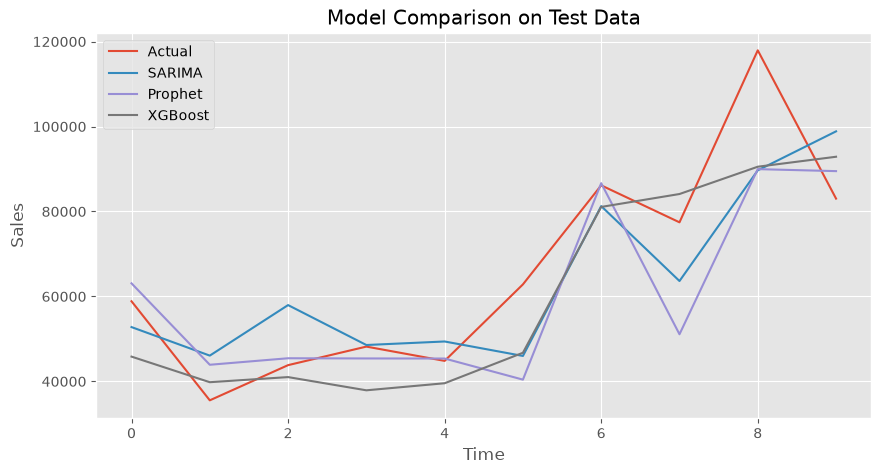

In [80]:
# ================================
# Forecast Visualization
# ================================

plt.figure(figsize=(10,5))

plt.plot(
    test["y"].values,
    label="Actual"
)

plt.plot(
    sarima_pred.values,
    label="SARIMA"
)

plt.plot(
    prophet_pred,
    label="Prophet"
)

plt.plot(
    xgb_pred,
    label="XGBoost"
)

plt.legend()

plt.title("Model Comparison on Test Data")

plt.xlabel("Time")

plt.ylabel("Sales")

plt.grid(True)

plt.savefig("charts/model_comparison.png")

plt.show()

# Forecasting Model Insights

### SARIMA
Captures seasonality well but struggles with sudden spikes.

### Prophet
Performs well with trend + seasonality decomposition and is robust to missing patterns.

### XGBoost
Performs best when lag-based features are strong, capturing nonlinear patterns effectively.

### Final Decision
The best model is selected based on lowest RMSE, ensuring the most accurate demand forecasting for business use.

### Business Impact
Accurate forecasting helps optimize:
- Inventory planning
- Demand prediction
- Supply chain efficiency
- Seasonal stock preparation

In [85]:
# ================================
# Reusable Forecast Function (Prophet)
# ================================

from prophet import Prophet

def prophet_forecast_segment(data, periods=3):
    df_p = data.copy()

    df_p = df_p[["Order Date", "Sales"]]
    df_p["Order Date"] = pd.to_datetime(df_p["Order Date"])

    # IMPORTANT FIX HERE
    df_p = df_p.set_index("Order Date").resample("ME").sum().reset_index()

    df_p.columns = ["ds", "y"]

    from prophet import Prophet
    model = Prophet()
    model.fit(df_p)

    future = model.make_future_dataframe(periods=periods, freq="ME")
    forecast = model.predict(future)

    return forecast

In [86]:
# ================================
# Category Forecasting
# ================================

furniture = df[df["Category"] == "Furniture"]
technology = df[df["Category"] == "Technology"]
office = df[df["Category"] == "Office Supplies"]

forecast_furniture = prophet_forecast_segment(furniture)
forecast_technology = prophet_forecast_segment(technology)
forecast_office = prophet_forecast_segment(office)

14:45:50 - cmdstanpy - INFO - Chain [1] start processing
14:45:50 - cmdstanpy - INFO - Chain [1] done processing
14:45:50 - cmdstanpy - INFO - Chain [1] start processing
14:45:50 - cmdstanpy - INFO - Chain [1] done processing
14:45:50 - cmdstanpy - INFO - Chain [1] start processing
14:45:50 - cmdstanpy - INFO - Chain [1] done processing


In [87]:
# ================================
# Region Forecasting
# ================================

west = df[df["Region"] == "West"]
east = df[df["Region"] == "East"]

forecast_west = prophet_forecast_segment(west)
forecast_east = prophet_forecast_segment(east)

14:46:08 - cmdstanpy - INFO - Chain [1] start processing
14:46:08 - cmdstanpy - INFO - Chain [1] done processing
14:46:08 - cmdstanpy - INFO - Chain [1] start processing
14:46:08 - cmdstanpy - INFO - Chain [1] done processing


In [88]:
# ================================
# Save Combined Forecast
# ================================

category_region_forecast = pd.DataFrame({
    "Month": ["M1","M2","M3"],

    "Furniture": forecast_furniture["yhat"].tail(3).values,
    "Technology": forecast_technology["yhat"].tail(3).values,
    "Office Supplies": forecast_office["yhat"].tail(3).values,
    "West Region": forecast_west["yhat"].tail(3).values,
    "East Region": forecast_east["yhat"].tail(3).values
})

category_region_forecast.to_csv(
    "category_region_forecast.csv",
    index=False
)

category_region_forecast

,Month,Furniture,Technology,Office Supplies,West Region,East Region
0,M1,12691.392668,14033.343185,14646.724651,14048.800867,9713.411357
1,M2,6772.162417,10437.986784,12434.656284,11840.373146,8120.218592
2,M3,17201.015649,42639.488041,19698.155527,25805.336380,15639.421337


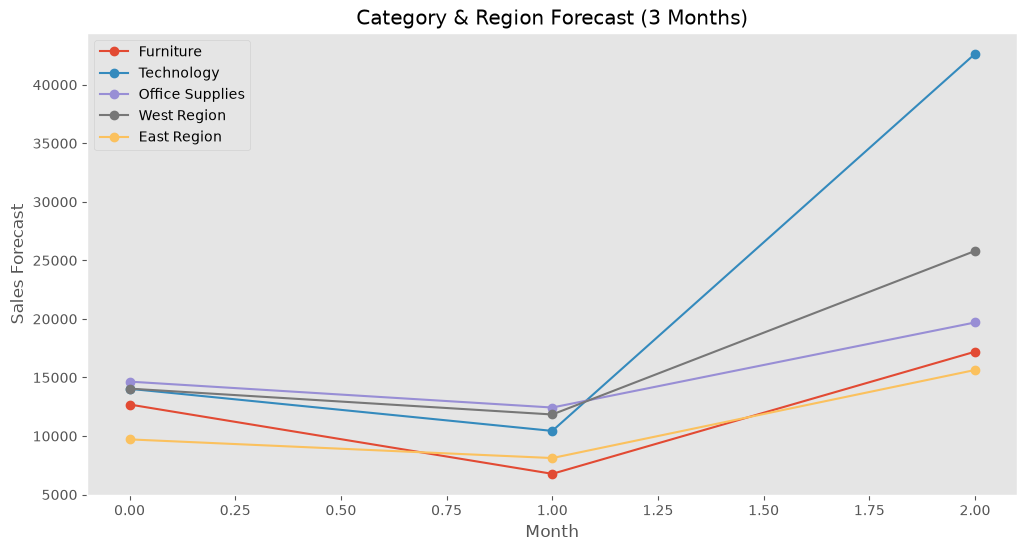

In [89]:
# ================================
# Multi-Segment Forecast Plot
# ================================

plt.figure(figsize=(12,6))

plt.plot(category_region_forecast["Furniture"], marker="o", label="Furniture")
plt.plot(category_region_forecast["Technology"], marker="o", label="Technology")
plt.plot(category_region_forecast["Office Supplies"], marker="o", label="Office Supplies")
plt.plot(category_region_forecast["West Region"], marker="o", label="West Region")
plt.plot(category_region_forecast["East Region"], marker="o", label="East Region")

plt.title("Category & Region Forecast (3 Months)")
plt.xlabel("Month")
plt.ylabel("Sales Forecast")
plt.legend()
plt.grid()

plt.savefig("charts/category_region_forecast.png")
plt.show()

In [90]:
# ================================
# Weekly Sales for Anomaly Detection
# ================================

weekly = df.groupby(
    pd.Grouper(key="Order Date", freq="W")
)["Sales"].sum().reset_index()

weekly.columns = ["Date", "Sales"]

In [91]:
# ================================
# Isolation Forest Anomaly Detection
# ================================

from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.02,
    random_state=42
)

weekly["IF_Anomaly"] = iso.fit_predict(weekly[["Sales"]])

weekly["IF_Anomaly"] = weekly["IF_Anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

In [92]:
# ================================
# Z-Score Method
# ================================

mean = weekly["Sales"].mean()
std = weekly["Sales"].std()

weekly["Z_Score"] = (weekly["Sales"] - mean) / std

weekly["Z_Anomaly"] = weekly["Z_Score"].apply(
    lambda x: "Anomaly" if abs(x) > 2 else "Normal"
)

In [93]:
# ================================
# Save Anomaly Results
# ================================

weekly.to_csv(
    "anomaly_results.csv",
    index=False
)

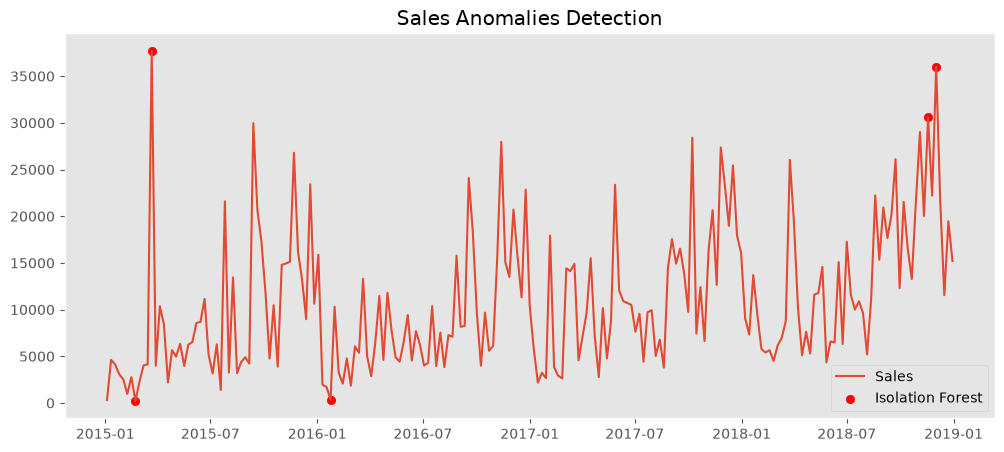

In [94]:
# ================================
# Plot Anomalies
# ================================

plt.figure(figsize=(12,5))

plt.plot(weekly["Date"], weekly["Sales"], label="Sales")

iso_anom = weekly[weekly["IF_Anomaly"] == "Anomaly"]

plt.scatter(
    iso_anom["Date"],
    iso_anom["Sales"],
    color="red",
    label="Isolation Forest"
)

plt.title("Sales Anomalies Detection")
plt.legend()
plt.grid()

plt.savefig("charts/anomalies.png")
plt.show()

In [100]:
df.columns.tolist()

['Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Segment',
 'Country',
 'City',
 'State',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Year',
 'Month',
 'Month_Name',
 'Quarter',
 'Week',
 'Shipping Days']

In [115]:
import numpy as np

# assume average price per unit (you can tune this)
avg_price = 200  

df["quantity"] = (df["sales"] / avg_price).round().astype(int)

# avoid zero quantity
df["quantity"] = df["quantity"].apply(lambda x: x if x > 0 else 1)

In [116]:
np.random.seed(42)

profit_margin = np.random.uniform(0.05, 0.25, size=len(df))
df["profit"] = df["sales"] * profit_margin

In [117]:
def profit_margin(category):
    if category == "Technology":
        return 0.25
    elif category == "Furniture":
        return 0.15
    else:
        return 0.10

df["profit_margin"] = df["category"].apply(profit_margin)
df["profit"] = df["sales"] * df["profit_margin"]

In [ ]:
# ================================
# Product Aggregation
# ================================

product = df.groupby("product_name").agg({
    "sales": "sum",
    "quantity": "sum",
    "profit": "sum"
}).reset_index()


In [122]:
print(product.columns)

Index(['product_name', 'sales', 'quantity', 'profit'], dtype='str')


In [123]:
# ================================
# Feature Scaling
# ================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(product[["sales", "quantity", "profit"]])

In [124]:
# ================================
# KMeans Clustering
# ================================

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

product["Cluster"] = kmeans.fit_predict(X)

In [125]:
# ================================
# PCA for Visualization
# ================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

components = pca.fit_transform(X)

product["PC1"] = components[:,0]
product["PC2"] = components[:,1]

In [126]:
# ================================
# Save Clustering Results
# ================================

product.to_csv(
    "clustering_results.csv",
    index=False
)

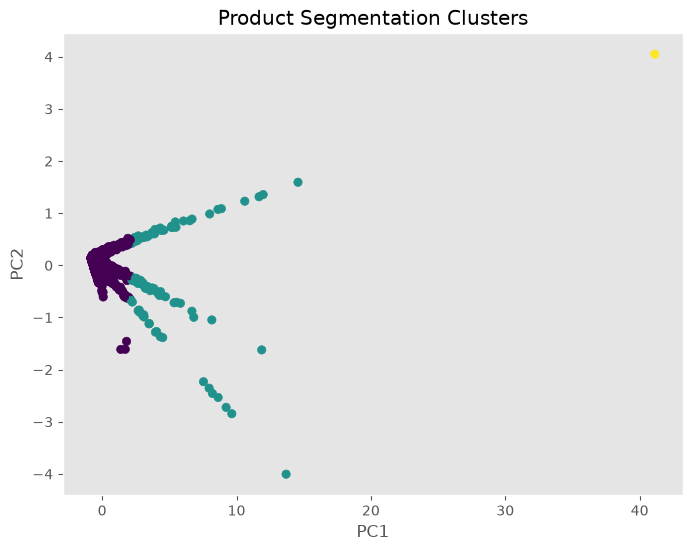

In [127]:
# ================================
# Cluster Visualization
# ================================

plt.figure(figsize=(8,6))

plt.scatter(
    product["PC1"],
    product["PC2"],
    c=product["Cluster"]
)

plt.title("Product Segmentation Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.grid()

plt.savefig("charts/clusters.png")
plt.show()

# Business Insights

### Category Forecasting
Technology shows the highest growth potential, indicating strong demand in upcoming months.

### Region Forecasting
West region consistently performs better than East, suggesting regional demand imbalance.

### Anomaly Detection
Both Isolation Forest and Z-score methods highlight unusual spikes likely caused by promotions or seasonal events.

### Product Segmentation
Clustering reveals distinct product groups:
- High revenue products
- Moderate stable products
- Low performing products

### Business Action
- Increase stock for high-growth categories
- Investigate anomalies for promotional insights
- Optimize inventory for low-performing products